## Installation

In [ ]:
!pip install evret opik

In [10]:
!pip install fastembed pypdfium2 evret[qdrant]

In [12]:
!wget https://arxiv.org/pdf/2210.03629.pdf -O react_paper.pdf

--2026-05-10 21:12:47--  https://arxiv.org/pdf/2210.03629.pdf
Resolving arxiv.org (arxiv.org)... 151.101.195.42, 151.101.3.42, 151.101.131.42, ...
Connecting to arxiv.org (arxiv.org)|151.101.195.42|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /pdf/2210.03629 [following]
--2026-05-10 21:12:47--  https://arxiv.org/pdf/2210.03629
Reusing existing connection to arxiv.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 633805 (619K) [application/pdf]
Saving to: ‘react_paper.pdf’

react_paper.pdf     100%[===================>] 618.95K  --.-KB/s    in 0.03s   

2026-05-10 21:12:47 (22.4 MB/s) - ‘react_paper.pdf’ saved [633805/633805]



In [4]:
import os

os.environ['OPIK_API_KEY'] = "<replace-with-api-key>" # https://www.comet.com/opik
os.environ["OPIK_WORKSPACE"] = "tarun-r-jain" # replace with your workspace
os.environ["OPIK_PROJECT_NAME"] = "evals" # create a new project

In [5]:
from fastembed import TextEmbedding
import pypdfium2 as pdfium
from qdrant_client import QdrantClient, models

In [6]:
QDRANT_URL = "" # cloud.qdrant.io (similar to demo-qdrant)
QDRANT_API_KEY = "" # cloud.qdrant.io

In [7]:
def load_pdf_chunks(pdf_path: str, chunk_size: int = 500) -> list[str]:
    """Load PDF and split into chunks."""
    pdf = pdfium.PdfDocument(pdf_path)
    text = " ".join(page.get_textpage().get_text_range() for page in pdf)
    words = text.split()
    return [" ".join(words[i : i + chunk_size]) for i in range(0, len(words), chunk_size)]

In [8]:
def index_documents(chunks: list[str], collection_name: str) -> None:
    """Index documents in Qdrant - this only needs to be done once."""
    print(f"Indexing {len(chunks)} chunks...")

    model = TextEmbedding(model_name="BAAI/bge-small-en-v1.5")
    vectors = [list(vector) for vector in model.embed(chunks)]

    client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)
    client.create_collection(
        collection_name=collection_name,
        vectors_config=models.VectorParams(
            size=len(vectors[0]),
            distance=models.Distance.COSINE
        )
    )
    points = [
        models.PointStruct(
            id=i,
            vector=vec,
            payload={"doc_id": f"doc_{i}", "text": chunk}
        )
        for i, (vec, chunk) in enumerate(zip(vectors, chunks))
    ]
    client.upsert(collection_name=collection_name, points=points)
    print(f"indexing done")

In [9]:
def main():
    """Index the documents."""
    COLLECTION_NAME = "react_paper"
    PDF_PATH = "react_agent_paper.pdf"

    chunks = load_pdf_chunks(PDF_PATH)
    index_documents(chunks, COLLECTION_NAME)

if __name__ == "__main__":
    main()

Indexing 34 chunks...
indexing done


## Inference

In [10]:
from fastembed import TextEmbedding
from qdrant_client import QdrantClient

from evret import EvaluationDataset, Evaluator
from evret.evaluation.dataset import QueryExample
from evret.judges import TokenOverlapJudge
from evret.metrics import HitRate, MRR, NDCG, Precision, Recall
from evret.retrievers import QdrantRetriever

In [11]:
QUERY_MODEL = TextEmbedding(model_name="BAAI/bge-small-en-v1.5")

def encode_query(query: str) -> list[float]:
    """Encode a single query into a vector."""
    return list(next(QUERY_MODEL.embed([query])))

In [12]:
def create_retriever(collection_name: str) -> QdrantRetriever:
    """Connect to existing Qdrant collection and create retriever"""
    client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)

    return QdrantRetriever(
        collection_name=collection_name,
        client=client,
        query_encoder=encode_query,
    )

In [13]:
def create_dataset() -> EvaluationDataset:
    """Create a minimal demo dataset for illustration."""
    dataset = EvaluationDataset(
        queries=[
            QueryExample(
                query_id="q1",
                query_text="What is the ReAct framework?",
                expected_answers=[
                    "ReAct combines reasoning traces with task-specific actions."
                ],
            ),
            QueryExample(
                query_id="q2",
                query_text="How does ReAct improve performance over reasoning-only or acting-only baselines?",
                expected_answers=[
                    "Interleaving reasoning and action helps the model gather external information and reduces hallucinations."
                ],
            ),
            QueryExample(
                query_id="q3",
                query_text="Why are reasoning traces useful in ReAct agents?",
                expected_answers=[
                    "Reasoning traces help the model induce, track, and update action plans while improving interpretability."
                ],
            ),
        ],
    )
    return dataset

In [31]:
import opik
from opik import opik_context

In [30]:
client = opik.Opik()
dataset = client.get_or_create_dataset(name="React paper", project_name="evals")

In [23]:
generated_dataset = create_dataset()

In [26]:
generated_dataset.queries

[QueryExample(query_id='q1', query_text='What is the ReAct framework?', relevant_doc_ids=[], expected_answers=['ReAct combines reasoning traces with task-specific actions.']),
 QueryExample(query_id='q2', query_text='How does ReAct improve performance over reasoning-only or acting-only baselines?', relevant_doc_ids=[], expected_answers=['Interleaving reasoning and action helps the model gather external information and reduces hallucinations.']),
 QueryExample(query_id='q3', query_text='Why are reasoning traces useful in ReAct agents?', relevant_doc_ids=[], expected_answers=['Reasoning traces help the model induce, track, and update action plans while improving interpretability.'])]

In [28]:
dataset.insert([{"input":data.query_text,"expected_answers":data.expected_answers} for data in generated_dataset.queries])

> check your OPIK dashboard Test Suites

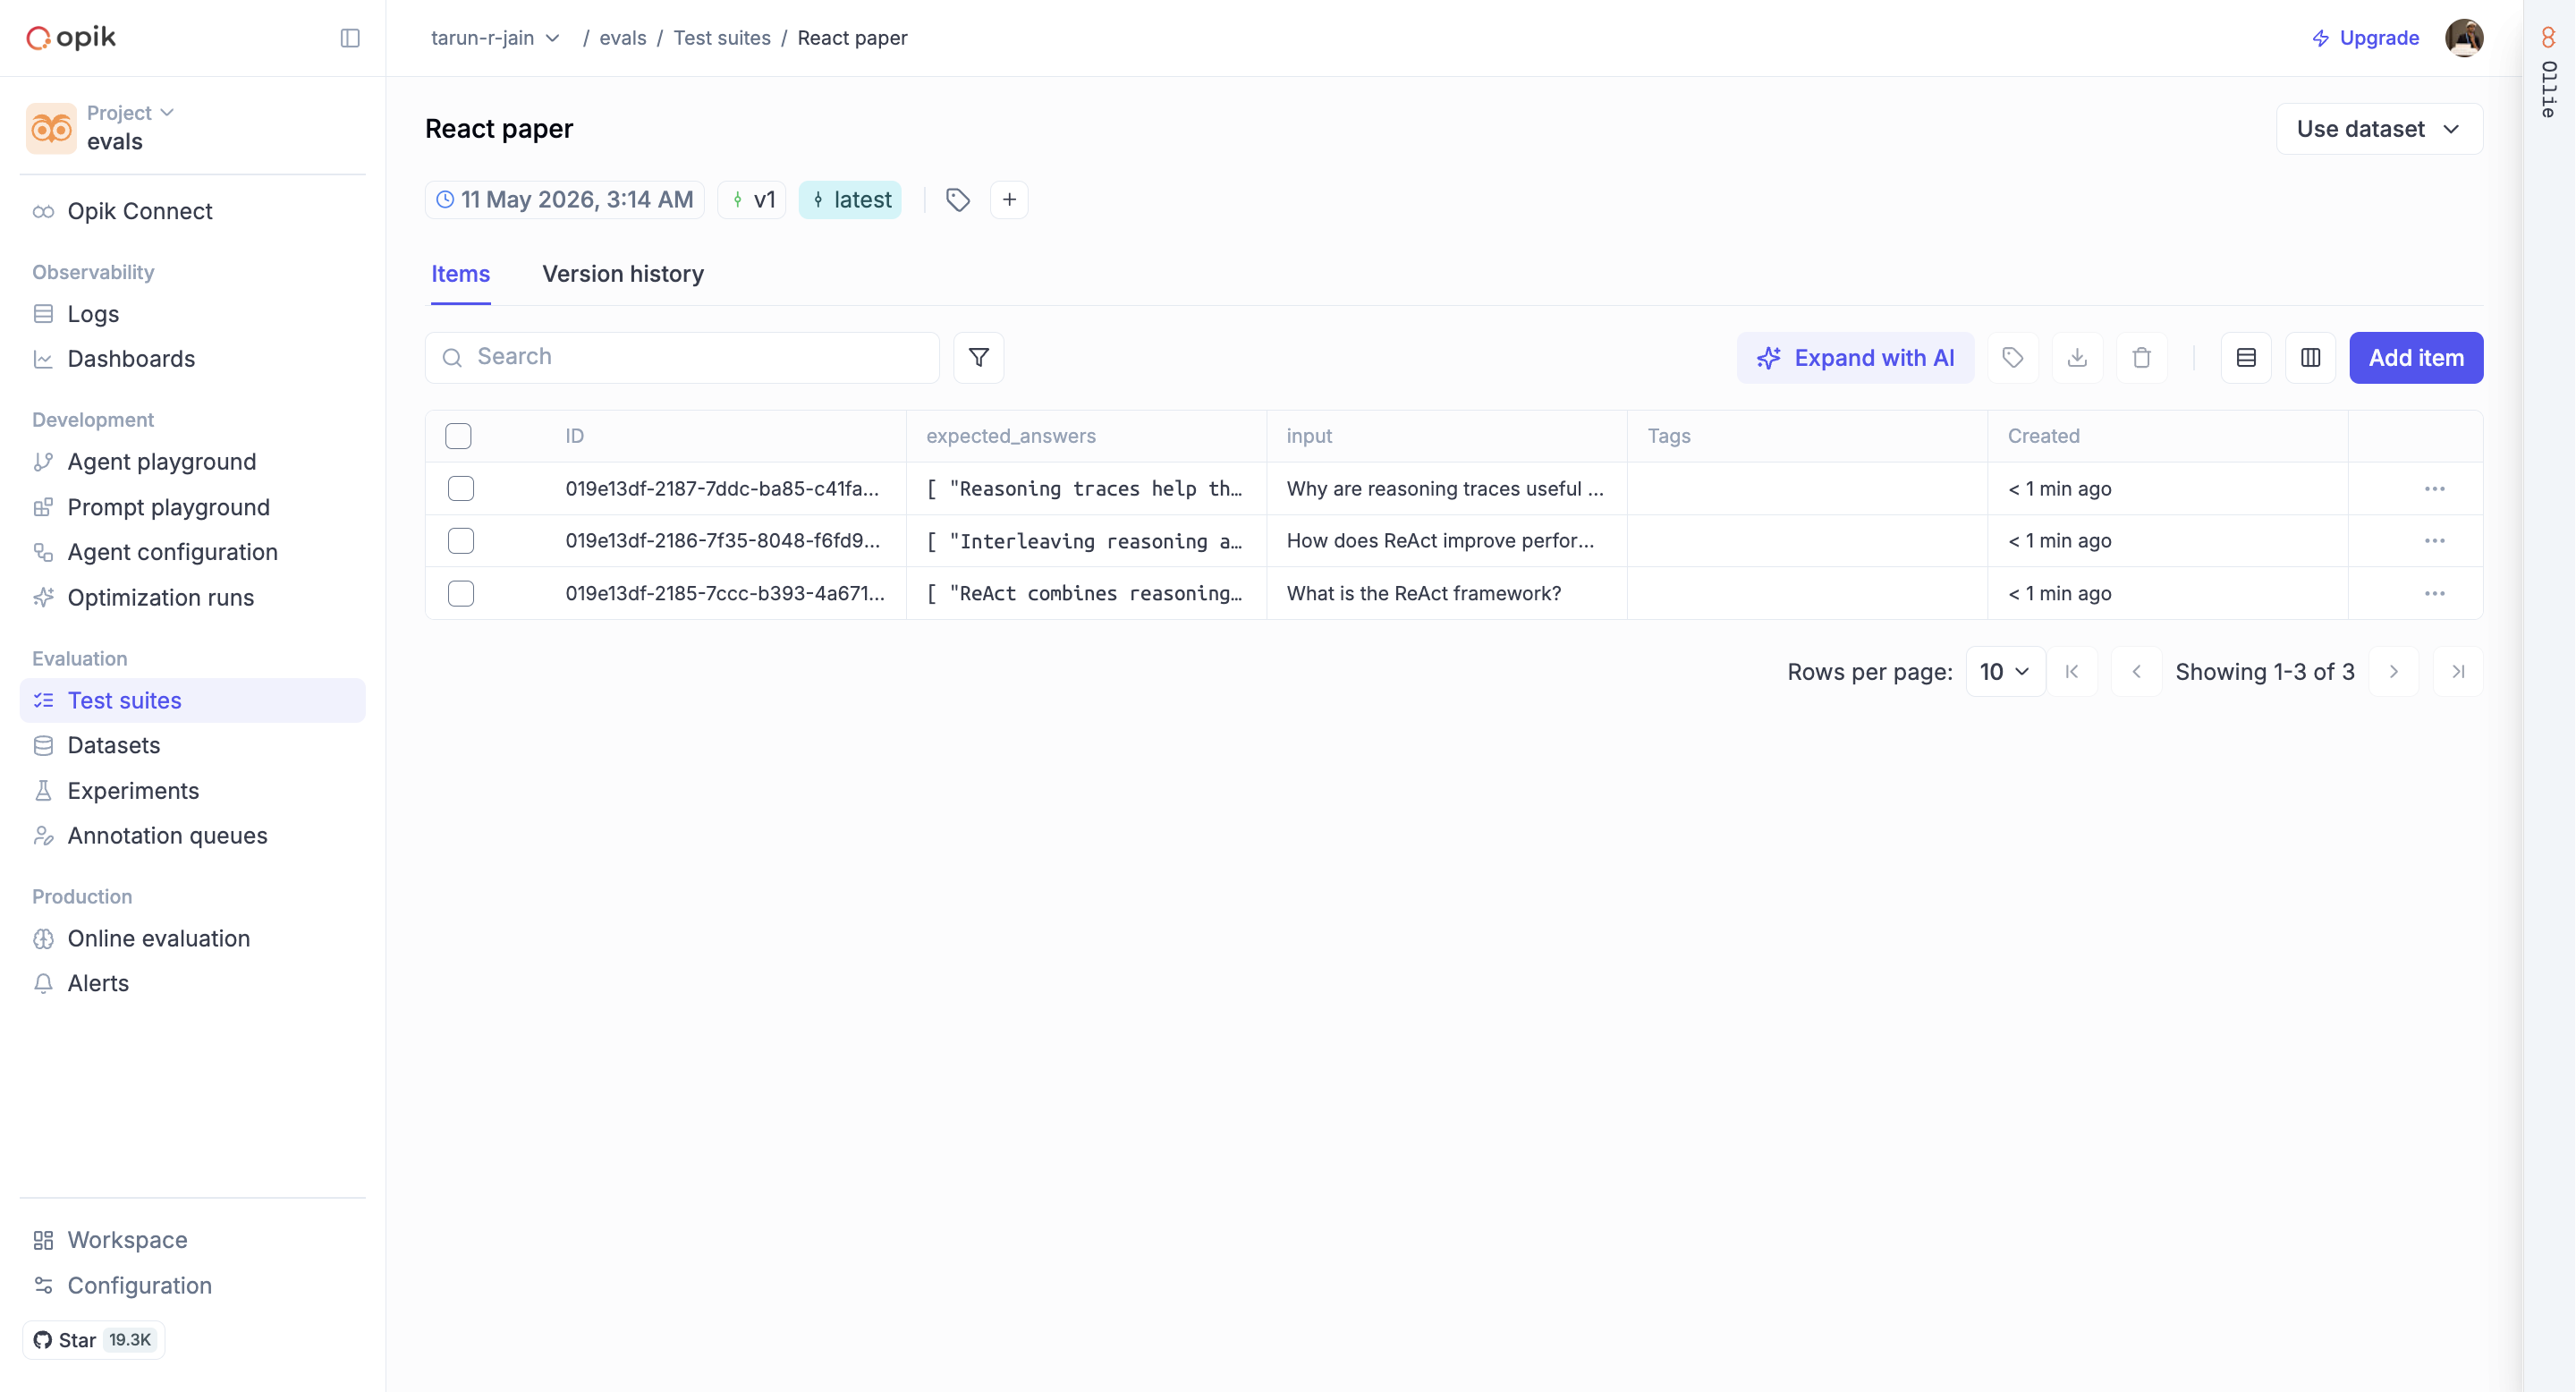

In [32]:
@opik.track
def inference(k):
    """Run evaluation on the indexed collection."""
    COLLECTION_NAME = "react_paper"
    retriever = create_retriever(COLLECTION_NAME)

    # Debug: retriever response
    print("\n=== DEBUGGING RETRIEVAL ===\n")
    for query_example in generated_dataset.queries:
        print(f"Query: {query_example.query_text}")
        print(f"Expected Answer: {query_example.expected_answers[0][:100]}...")

        retrieved_docs = retriever.retrieve(query_example.query_text, k=k)

        print(f"\nRetrieved {len(retrieved_docs)} documents:")
        for doc in retrieved_docs:
            print(doc)
        print("\n" + "="*50 + "\n")

    metrics = [
        HitRate(k=k),Precision(k=k),
        Recall(k=k),MRR(k=k), NDCG(k=k),
    ]
    judge = TokenOverlapJudge(min_tokens=5, overlap_ratio=0.5)
    evaluator = Evaluator(retriever=retriever, metrics=metrics, judge=judge)

    results = evaluator.evaluate(generated_dataset).summary()

    opik_context.update_current_trace(
        feedback_scores=[
            {"name": "hit_rate@4",  "value": results.get("hit_rate@4",  0.0)},
            {"name": "precision@4", "value": results.get("precision@4", 0.0)},
            {"name": "recall@4",    "value": results.get("recall@4",    0.0)},
            {"name": "mrr@4",       "value": results.get("mrr@4",       0.0)},
            {"name": "ndcg@4",      "value": results.get("ndcg@4",      0.0)},
        ]
    )

In [34]:
if __name__ == "__main__":
    inference(k=4)

OPIK: Started logging traces to the "evals" project at https://www.comet.com/opik/api/v1/session/redirect/projects/?trace_id=019e13e6-4338-756b-bd2b-724c585442f4&path=aHR0cHM6Ly93d3cuY29tZXQuY29tL29waWsvYXBpLw==.



=== DEBUGGING RETRIEVAL ===

Query: What is the ReAct framework?
Expected Answer: ReAct combines reasoning traces with task-specific actions....

Retrieved 4 documents:
RetrievalResult(doc_id='doc_1', score=0.743551, metadata={'doc_id': 'doc_1', 'text': 'derive ∗Work during Google internship. Projet page with code: https://react-lm.github.io/. 1 arXiv:2210.03629v3 [cs.CL] 10 Mar 2023 Published as a conference paper at ICLR 2023 $FW\x14 7KLQN>)LUVW,QHHGWRILQGDSHSSHUVKDNHU\x11\x11\x11PRUH OLNHO\\WRDSSHDULQFDELQHWV \x14\x10\x19 \x0fFRXQWHUWRSV \x14\x10\x16 \x0f\x11\x11\x11 @ $FW\x15 *RWRFDELQHW\x14 2EV\x15 2QWKHFDELQHW\x14\x0f\\RXVHHDYDVH\x15\x11 +HUHWKHDJHQWJRWRFDELQHW\x14\x0fWKHQFDELQHW\x15\x0f\x16\x0fWKHQFRXQWHUWRS\x14DQG\x15 $FW\x19 *RWRFRXQWHUWRS\x16 2EV\x19 2QWKHFRXQWHUWRS\x16\x0f\\RXVHHDDSSOH\x14\x0fDEUHDG\x14\x0f \x11\x11\x11\x11\x11\x11DSHSSHUVKDNHU\x14\x0fDQGDYDVH\x16\x11 $FW\x1a 7DNHSHSSHUVKDNHU\x14IURPFRXQWHUWRS\x16 2EV\x1a <RXSLFNXSWKHSHSSHUVKDNHU\x14IURPWKHFRXQWHUWRS\x16\x1

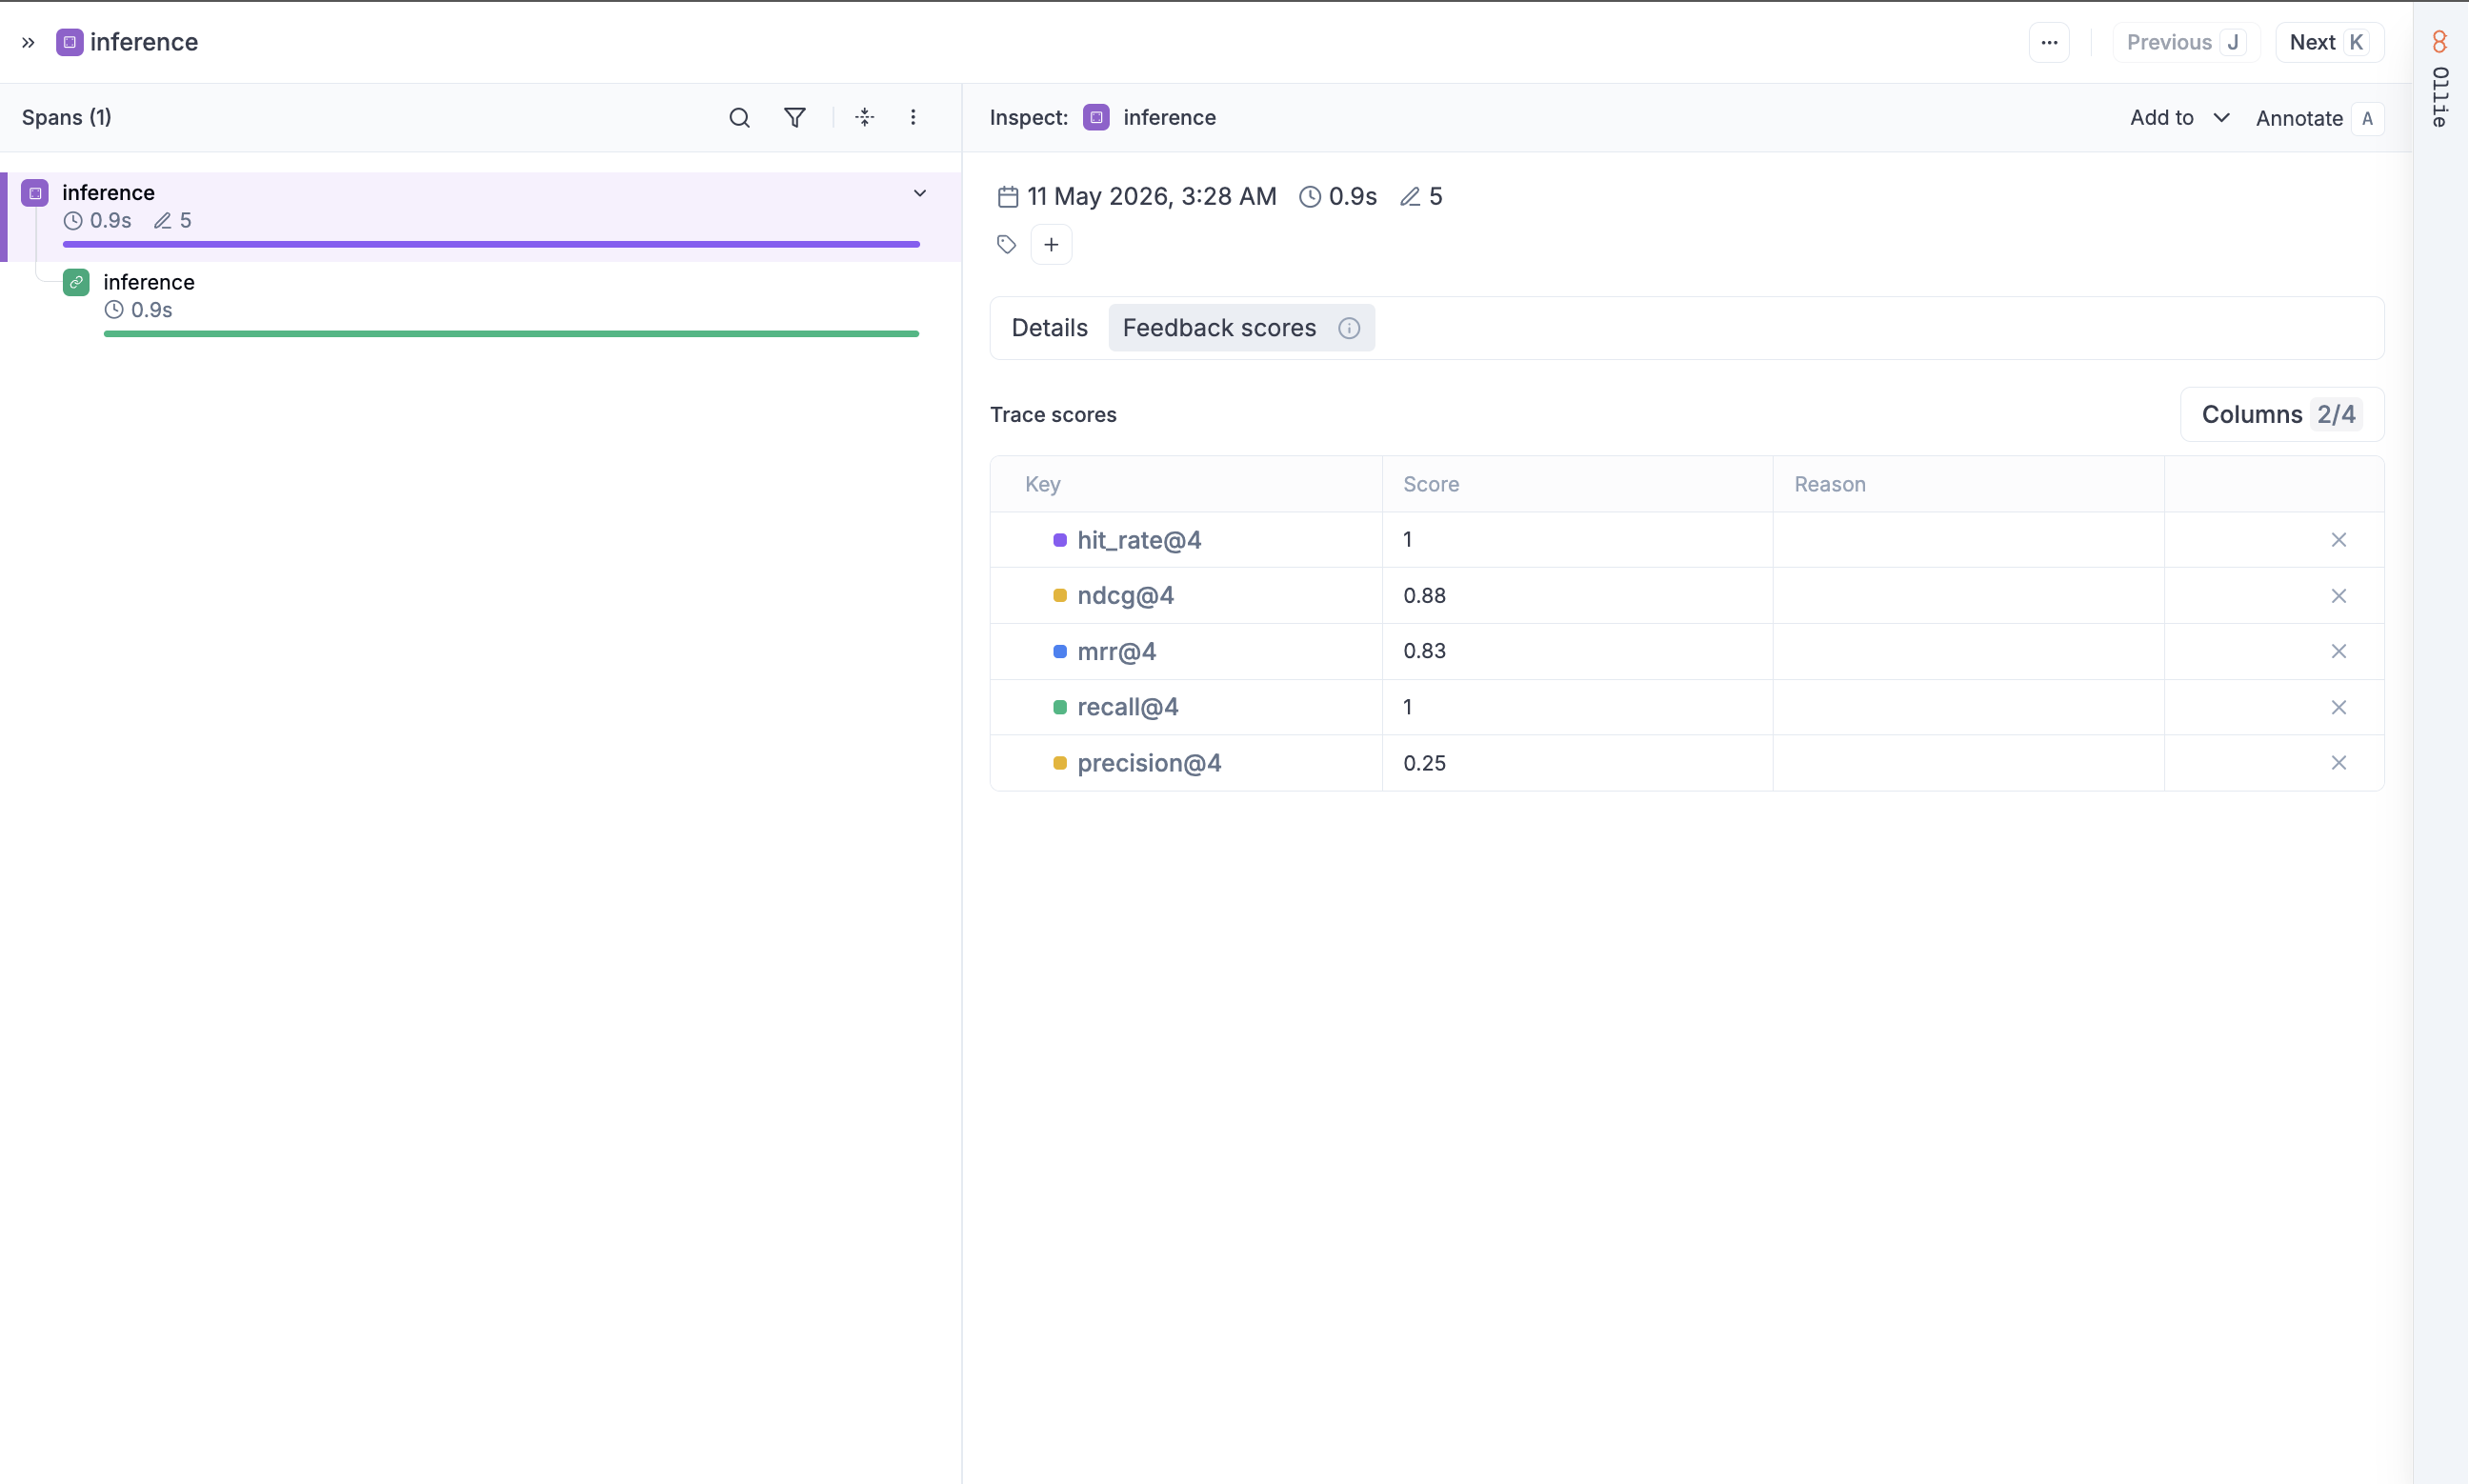